# Problem Statement

Forecast future energy demand to support capacity planning and resource optimization.


In [7]:
import pandas as pd

df = pd.read_csv(r"\\Hourly_Energy_Consumption\PJME_hourly.csv")
df.head(10)



,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0
5,2002-12-31 06:00:00,26222.0
6,2002-12-31 07:00:00,28702.0
7,2002-12-31 08:00:00,30698.0
8,2002-12-31 09:00:00,31800.0
9,2002-12-31 10:00:00,32359.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  object 
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.2+ MB


In [6]:
df.describe()

,PJME_MW
count,145366.000000
mean,32080.222831
std,6464.012166
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


In [13]:
df.columns

Index(['PJME_MW'], dtype='object')

## Convert Index to Datetime

In [14]:
df.index = pd.to_datetime(df.index)


## Renaming Column


In [15]:
df = df.rename(columns={'PJME_MW': 'consumption'})

## Sort Index

Time series models rely on temporal order. Sorting ensures that past observations precede future ones, which is critical for correct model training, validation, and forecasting.

In [16]:
df = df.sort_index()

In [18]:
df.index.is_monotonic_increasing

True

## Plotting the Data

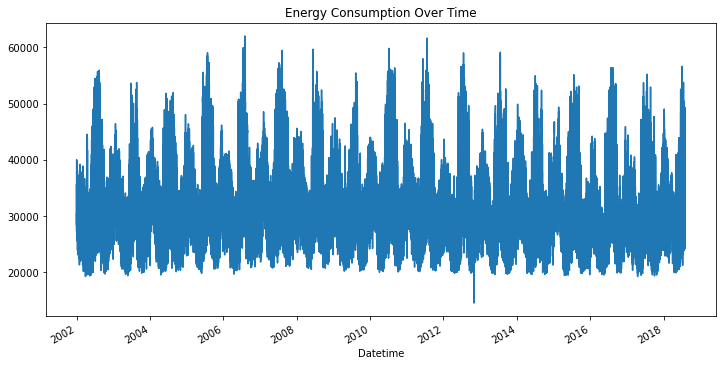

In [17]:
import matplotlib.pyplot as plt

df['consumption'].plot(figsize=(12,6))
plt.title("Energy Consumption Over Time")
plt.show()

## Investigate Structural Break between 2012 & 2014

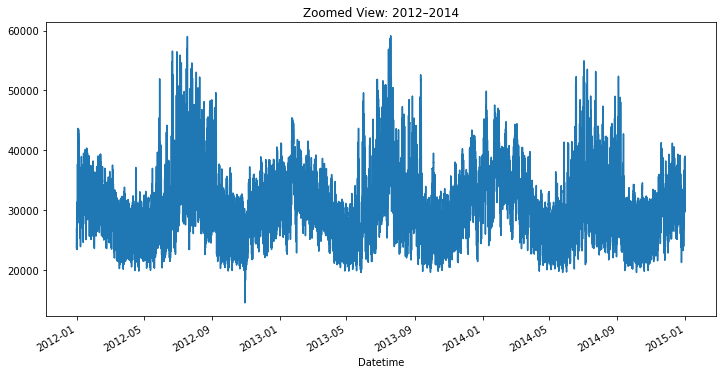

In [19]:
df.loc['2012':'2014']['consumption'].plot(figsize=(12,6))
plt.title("Zoomed View: 2012–2014")
plt.show()

In [20]:
df.loc['2012':'2014'].describe()

,consumption
count,26300.000000
mean,31547.577719
std,6300.985072
min,14544.000000
25%,27208.000000
50%,30775.000000
75%,35087.250000
max,59122.000000


In [21]:
df.loc['2012':'2014'].isnull().sum()

consumption    0
dtype: int64

## Stationarity Testing (ADF Test)

In [22]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['consumption'])

print('ADF Statistic:', result[0])
print('p-value:', result[1])

C:\Users\Jean-Marie Chukwuma\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:7: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import (to_datetime, Int64Index, DatetimeIndex, Period,
C:\Users\Jean-Marie Chukwuma\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:7: FutureWarning: pandas.Float64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import (to_datetime, Int64Index, DatetimeIndex, Period,


ADF Statistic: -19.88134841399188
p-value: 0.0


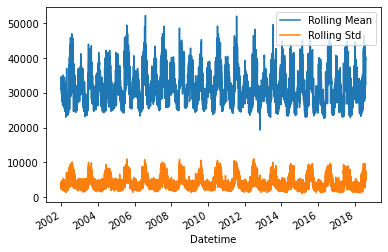

In [23]:
df['consumption'].rolling(window=24).mean().plot(label='Rolling Mean')
df['consumption'].rolling(window=24).std().plot(label='Rolling Std')
plt.legend()
plt.show()

The Augmented Dickey-Fuller test indicates stationarity (p < 0.05). However, visual inspection reveals clear seasonal patterns and potential structural changes, suggesting the need for models that can capture seasonality, such as SARIMA.

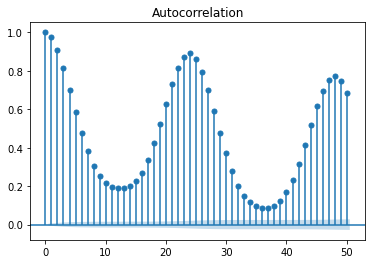

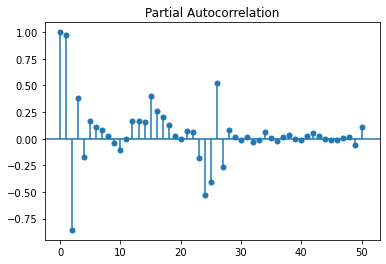

In [24]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df['consumption'], lags=50)
plot_pacf(df['consumption'], lags=50)

plt.show()

The ACF plot shows repeating spikes at regular intervals, indicating strong seasonality in the data. Given the hourly frequency, this likely reflects daily and weekly consumption patterns.

In [25]:
print(24*7)

168


## Build SARIMA Model

In [26]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    df['consumption'],
    order=(1,0,1),              # ARIMA part
    seasonal_order=(1,0,1,24)   # Seasonal part (daily)
)

results = model.fit()

print(results.summary())

C:\Users\Jean-Marie Chukwuma\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:581: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  warnings.warn('A date index has been provided, but it has no'
C:\Users\Jean-Marie Chukwuma\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:581: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  warnings.warn('A date index has been provided, but it has no'
C:\Users\Jean-Marie Chukwuma\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                                     SARIMAX Results                                      
Dep. Variable:                        consumption   No. Observations:               145366
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 24)   Log Likelihood            -1064359.575
Date:                            Mon, 13 Apr 2026   AIC                        2128729.150
Time:                                    22:18:26   BIC                        2128778.585
Sample:                                         0   HQIC                       2128743.905
                                         - 145366                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9823      0.000   2358.479      0.000       0.982       0.983
ma.L1          0.7374      0.001   

In [32]:
duplicate_count = df.index.duplicated().sum()
print("Duplicate timestamps:", duplicate_count)

Duplicate timestamps: 4


In [33]:
df[df.index.duplicated(keep=False)].sort_index().head(20)

,consumption
Datetime,
2014-11-02 02:00:00,23755.0
2014-11-02 02:00:00,22935.0
2015-11-01 02:00:00,21567.0
2015-11-01 02:00:00,21171.0
2016-11-06 02:00:00,20795.0
2016-11-06 02:00:00,21692.0
2017-11-05 02:00:00,21236.0
2017-11-05 02:00:00,20666.0


In [34]:
df = df.groupby(df.index).mean()

In [35]:
df = df.sort_index()
df = df.asfreq('H')

In [36]:
print(df.isnull().sum())

consumption    30
dtype: int64


In [37]:
df['consumption'] = df['consumption'].interpolate(method='time')

In [38]:
print(df.index.is_monotonic_increasing)
print(df.index.duplicated().sum())
print(df.isnull().sum())

True
0
consumption    0
dtype: int64


In [39]:
train = df.iloc[:-168]   # leave last week for testing
test = df.iloc[-168:]

In [42]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train['consumption'],
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(maxiter=200)

forecast = results.get_forecast(steps=len(test))
predictions = forecast.predicted_mean
predictions.index = test.index

In [43]:
print(predictions.head())
print(predictions.tail())
print(type(predictions))
print(len(predictions))

Datetime
2018-07-27 01:00:00    33200.704296
2018-07-27 02:00:00    31638.485398
2018-07-27 03:00:00    30600.000431
2018-07-27 04:00:00    30032.301871
2018-07-27 05:00:00    30096.627940
Freq: H, Name: predicted_mean, dtype: float64
Datetime
2018-08-02 20:00:00    41453.524340
2018-08-02 21:00:00    40398.198657
2018-08-02 22:00:00    39040.756997
2018-08-02 23:00:00    36391.170427
2018-08-03 00:00:00    33555.820644
Freq: H, Name: predicted_mean, dtype: float64
<class 'pandas.core.series.Series'>
168


In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test['consumption'], predictions)
rmse = np.sqrt(mean_squared_error(test['consumption'], predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 3301.3833837763354
RMSE: 3766.5270488597757


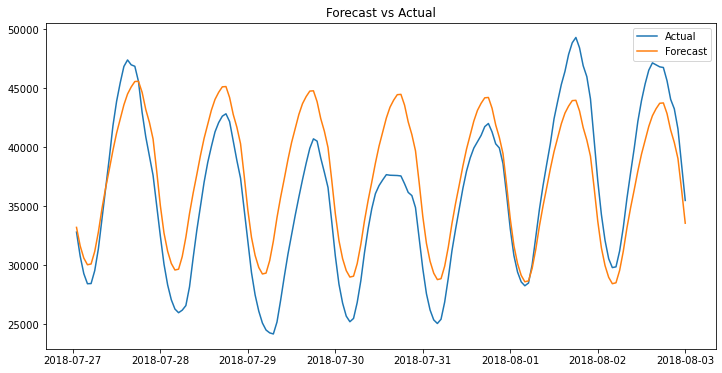

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(test.index, test['consumption'], label='Actual')
plt.plot(predictions.index, predictions, label='Forecast')
plt.title("Forecast vs Actual")
plt.legend()
plt.show()

The SARIMA model successfully captured the seasonal patterns in the data, particularly daily consumption cycles. However, it tended to overestimate peak demand, likely due to the model’s inability to capture sudden spikes and the absence of external variables such as weather. This suggests that while the model performs well for general forecasting, it could be improved with additional features or alternative models.

## Weekly Seasonality


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train['consumption'],
    order=(1, 0, 0),
    seasonal_order=(1, 0, 1, 168),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(maxiter=200)

forecast = results.get_forecast(steps=len(test))
predictions = forecast.predicted_mean
predictions.index = test.index

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(test.index, test['consumption'], label='Actual')
plt.plot(predictions.index, predictions, label='Forecast')
plt.title("Forecast vs Actual")
plt.legend()
plt.show()

## Random Forest/XGBoost

In [47]:
df_ml = df.copy()

df_ml['hour'] = df_ml.index.hour
df_ml['dayofweek'] = df_ml.index.dayofweek
df_ml['month'] = df_ml.index.month

df_ml['lag_1'] = df_ml['consumption'].shift(1)
df_ml['lag_24'] = df_ml['consumption'].shift(24)
df_ml['lag_168'] = df_ml['consumption'].shift(168)

df_ml = df_ml.dropna()

In [48]:
train_ml = df_ml.iloc[:-168]
test_ml = df_ml.iloc[-168:]

In [49]:
features = ['hour', 'dayofweek', 'month', 'lag_1', 'lag_24', 'lag_168']

X_train = train_ml[features]
y_train = train_ml['consumption']

X_test = test_ml[features]
y_test = test_ml['consumption']

In [50]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)

model_rf.fit(X_train, y_train)

rf_predictions = model_rf.predict(X_test)

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_rf = mean_absolute_error(y_test, rf_predictions)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_predictions))

print("RF MAE:", mae_rf)
print("RF RMSE:", rmse_rf)

RF MAE: 311.89083333333326
RF RMSE: 407.8951403065674


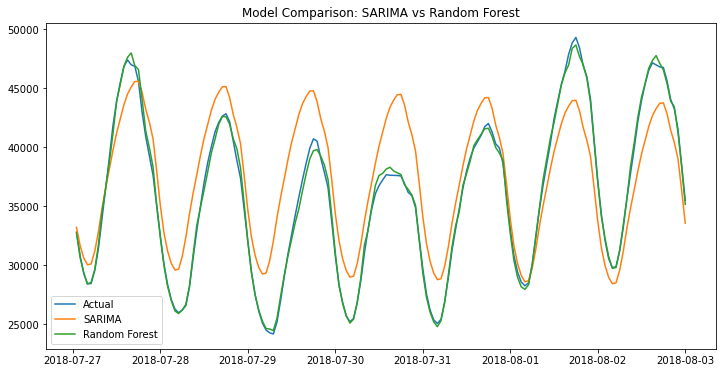

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(test.index, test['consumption'], label='Actual')
plt.plot(predictions.index, predictions, label='SARIMA')
plt.plot(test_ml.index, rf_predictions, label='Random Forest')

plt.legend()
plt.title("Model Comparison: SARIMA vs Random Forest")
plt.show()

I compared a SARIMA model with a Random Forest model for forecasting energy demand. While SARIMA effectively captured seasonal trends, it struggled with peak values. The Random Forest model significantly outperformed SARIMA, achieving much lower MAE and RMSE, and better captured peak demand due to its ability to model non-linear relationships using lag-based features.